In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import itertools as it
import warnings
warnings.simplefilter("ignore", RuntimeWarning)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd

import cogwheel.cosmology
import cogwheel.data
import cogwheel.posterior
import cogwheel.sampling
import cogwheel.gw_plotting
import cogwheel.gw_utils
import cogwheel.utils
from cogwheel.likelihood.marginalization.coherent_score_lensing import CoherentScoreLensing, \
                                                                        bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
from helpers import load_event_data_and_posterior_samples, plot_posterior_samples, get_pII_median_span, expected_lnB

In [3]:
# load injection results
mchirp = 30.    # Msun

iota = 0.5 * np.pi
q = 0.5

dLs = np.arange(100., 1001., 100) # Mpc

seed = 14
prior_class = 'IntrinsicLVCPrior'

# load our posterior samples and the released samples from the LVK PE
resdir = f'/home/abbye.williams/GWPE/data/pe_runs_lensing/injections/d_luminosity/mchirp-{mchirp:.2f}/{prior_class}'

# number of resamples for Bayes factor bootstrap
n_resamples = 1000

In [15]:
# get the SNR and compute the Bayes factor
# calculate the Bayes factors
h_h = {}
lnBayes = {}
for dL in dLs:
    # load this sample
    eventname = f'GW{seed}_iota-{iota / np.pi:.2f}_q-{q:.2f}_dL-{int(dL)}Mpc'
    eventdir = os.path.join(resdir, eventname)
    event_data, samples = load_event_data_and_posterior_samples(eventdir, eventname)

    # optimal SNR: inner product from the injection
    h_h[dL] = np.sum(event_data.get_init_dict()['injection']['h_h'])

    # Bayes factor
    bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
    # log these
    lnBayes_factors = np.log(bayes_factors)
    # get the median and standard deviation
    lnBayes[dL] = (np.median(lnBayes_factors), np.std(lnBayes_factors))

loaded posterior samples for GW14_iota-0.50_q-0.50_dL-100Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-200Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-300Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-400Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-500Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-600Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-700Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-800Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-900Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-1000Mpc run 0


In [20]:
# print
for dL in dLs:
    med, std = lnBayes[dL]
    print(f"{dL} Mpc:\tln Bayes = {med:6.4f} ± {std:6.4f}\t\th_h = {h_h[dL]:.2f}")

100.0 Mpc:	ln Bayes =    nan ±    nan		h_h = 30032.13
200.0 Mpc:	ln Bayes =    nan ±    nan		h_h = 7508.03
300.0 Mpc:	ln Bayes = 19.8540 ± 0.2508		h_h = 3336.90
400.0 Mpc:	ln Bayes = 14.0107 ± 0.1971		h_h = 1877.01
500.0 Mpc:	ln Bayes = 10.0656 ± 0.1370		h_h = 1201.29
600.0 Mpc:	ln Bayes = 7.3677 ± 0.0785		h_h = 834.23
700.0 Mpc:	ln Bayes = 5.7507 ± 0.0555		h_h = 612.90
800.0 Mpc:	ln Bayes = 4.5262 ± 0.0359		h_h = 469.25
900.0 Mpc:	ln Bayes = 3.6212 ± 0.0280		h_h = 370.77
1000.0 Mpc:	ln Bayes = 2.9666 ± 0.0216		h_h = 300.32


In [22]:
lnBayes_vals = np.array([
    x[0] for x in lnBayes.values()
])

In [31]:
lnBayes_vals

array([        nan,         nan, 19.85401889, 14.01067553,
       10.06564869,  7.3677161 ,  5.75065163,  4.5262457 ,
        3.62120988,  2.96662719])

Text(0.5, 1.0, 'Injections: $(\\iota,q)=(0.5\\pi, 0.5)$')

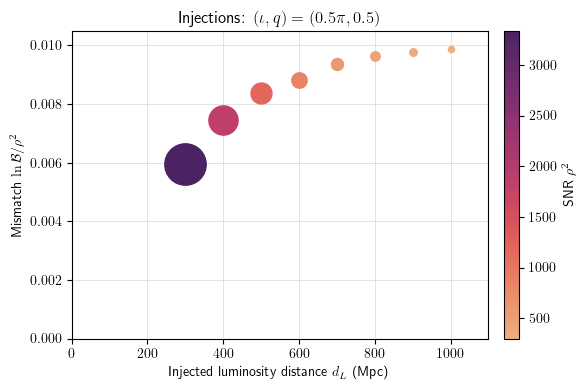

In [51]:
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
# norm = mpl.colors.Normalize(vmin=np.nanmin(lnBayes_vals), vmax=np.nanmax(lnBayes_vals))
norm = mpl.colors.Normalize(vmin=min(list(h_h.values())[2:]), vmax=max(list(h_h.values())[2:])) # hacky but to avoid the first two points where lnBayes is nan
smap = mpl.cm.ScalarMappable(norm=norm, cmap=sns.color_palette('flare', as_cmap=True))
for dL in dLs:
    ax.plot(dL, lnBayes[dL][0] / h_h[dL], ls='None', marker='o', c=smap.to_rgba(h_h[dL]), ms=lnBayes[dL][0] * 1.5)
ax.set_xlabel(r'Injected luminosity distance $d_L$ (Mpc)')
ax.set_ylabel(r'Mismatch $\ln\mathcal B/\rho^2$')
ax.set_xlim(0., 1100)
ax.set_ylim(0., 0.0105)
ax.grid(alpha=0.5, lw=0.5)
fig.colorbar(smap, ax=ax, label=r'SNR $\rho^2$', pad=0.03)
ax.set_title(r'Injections: $(\iota,q)=(0.5\pi, 0.5)$')

loaded posterior samples for GW14_iota-0.50_q-0.50_dL-100Mpc run 0
ValueError: plotting without p_lensed
another ValueError... continuing to next injection
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-200Mpc run 0
ValueError: plotting without p_lensed
another ValueError... continuing to next injection
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-300Mpc run 0
ValueError: plotting without p_lensed
another ValueError... continuing to next injection
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-400Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-500Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-600Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-700Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-800Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-900Mpc run 0
loaded posterior samples for GW14_iota-0.50_q-0.50_dL-1000Mpc run 0
Error in callback <function _draw_all_if_interactive at 0x7efd

RuntimeError: latex was not able to process the following string:
b'$t_{\\\\rm \\u2d32}$ (s)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpdam5e45p c4e635c550816a3980884dbb91cc902d.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.19 (TeX Live 2018) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./c4e635c550816a3980884dbb91cc902d.tex
LaTeX2e <2017-04-15>
Babel <3.17> and hyphenation patterns for 3 language(s) loaded.
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2014/09/29 v1.4h Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty
(/usr/share/texlive/texmf-dist/tex/latex/b

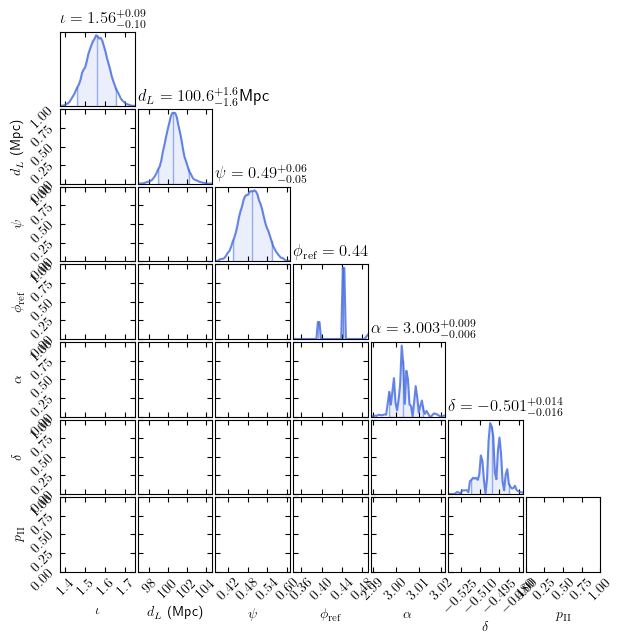

RuntimeError: latex was not able to process the following string:
b'$t_{\\\\rm \\u2d32}$ (s)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp7zwc3g7q c4e635c550816a3980884dbb91cc902d.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.19 (TeX Live 2018) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./c4e635c550816a3980884dbb91cc902d.tex
LaTeX2e <2017-04-15>
Babel <3.17> and hyphenation patterns for 3 language(s) loaded.
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2014/09/29 v1.4h Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty
(/usr/share/texlive/texmf-dist/tex/latex/b

<Figure size 700x700 with 1764 Axes>

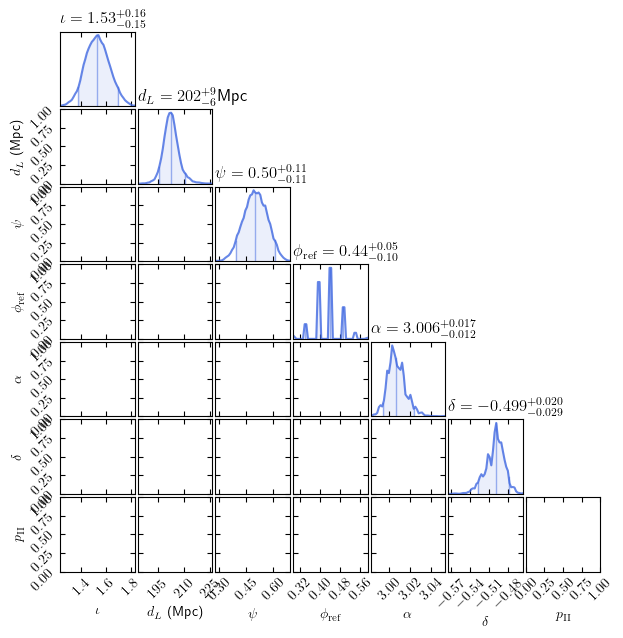

RuntimeError: latex was not able to process the following string:
b'$t_{\\\\rm \\u2d32}$ (s)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp0zruqcjs c4e635c550816a3980884dbb91cc902d.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.19 (TeX Live 2018) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./c4e635c550816a3980884dbb91cc902d.tex
LaTeX2e <2017-04-15>
Babel <3.17> and hyphenation patterns for 3 language(s) loaded.
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2014/09/29 v1.4h Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty
(/usr/share/texlive/texmf-dist/tex/latex/b

<Figure size 700x700 with 1764 Axes>

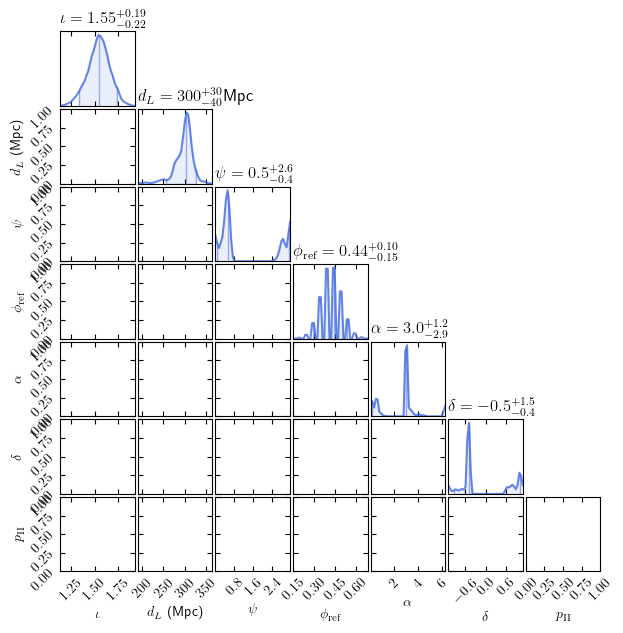

RuntimeError: latex was not able to process the following string:
b'$t_{\\\\rm \\u2d32}$ (s)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpf_hdkde5 c4e635c550816a3980884dbb91cc902d.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.19 (TeX Live 2018) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./c4e635c550816a3980884dbb91cc902d.tex
LaTeX2e <2017-04-15>
Babel <3.17> and hyphenation patterns for 3 language(s) loaded.
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2014/09/29 v1.4h Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty
(/usr/share/texlive/texmf-dist/tex/latex/b

<Figure size 700x700 with 1764 Axes>

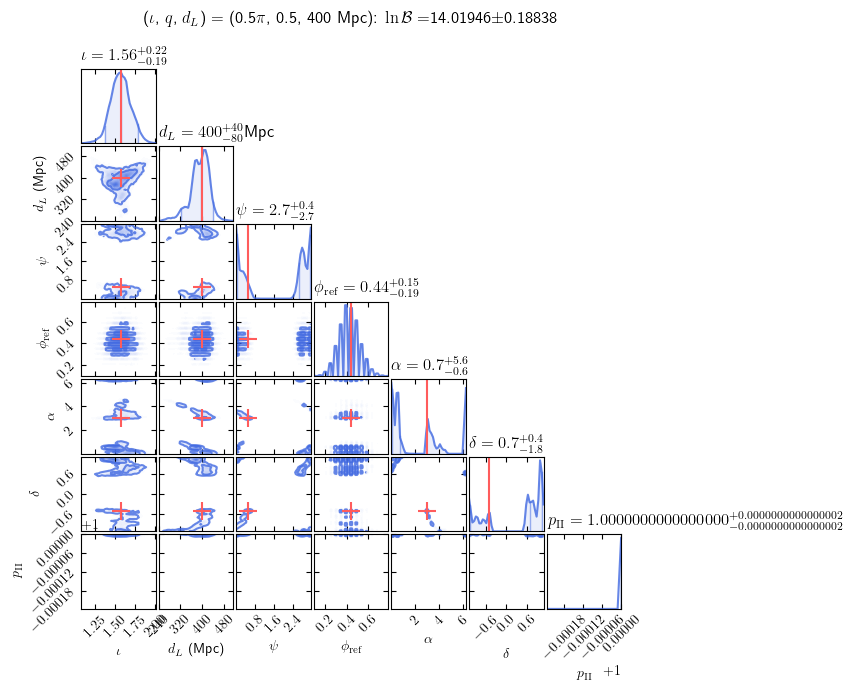

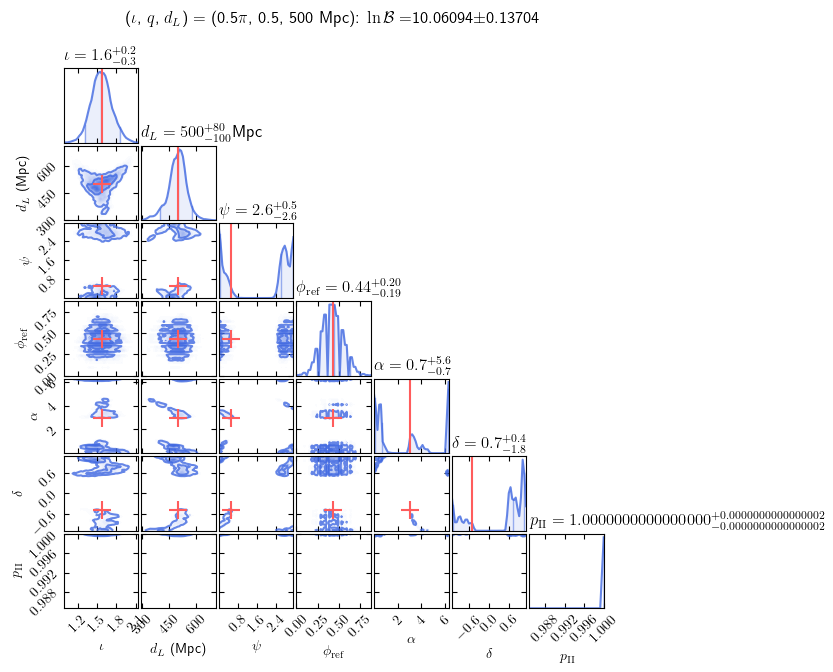

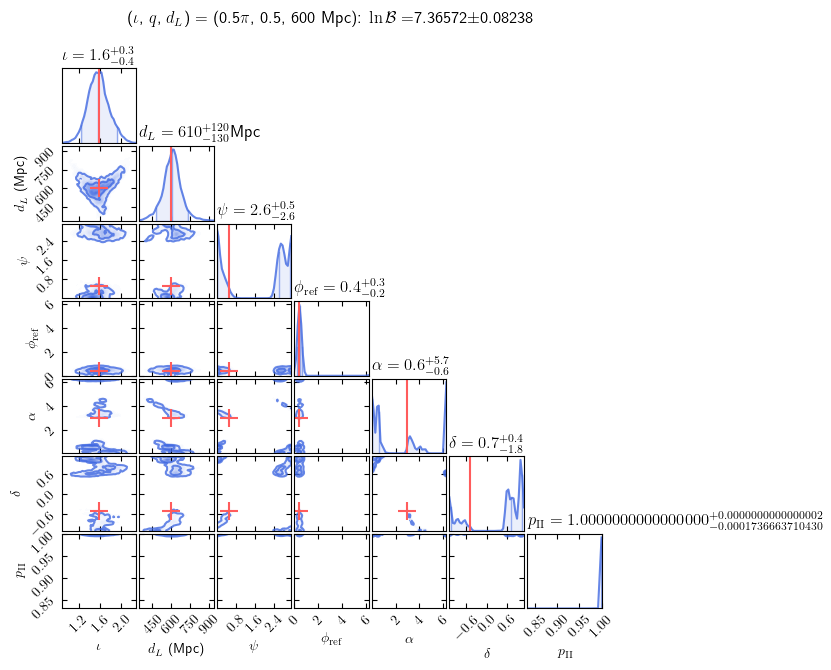

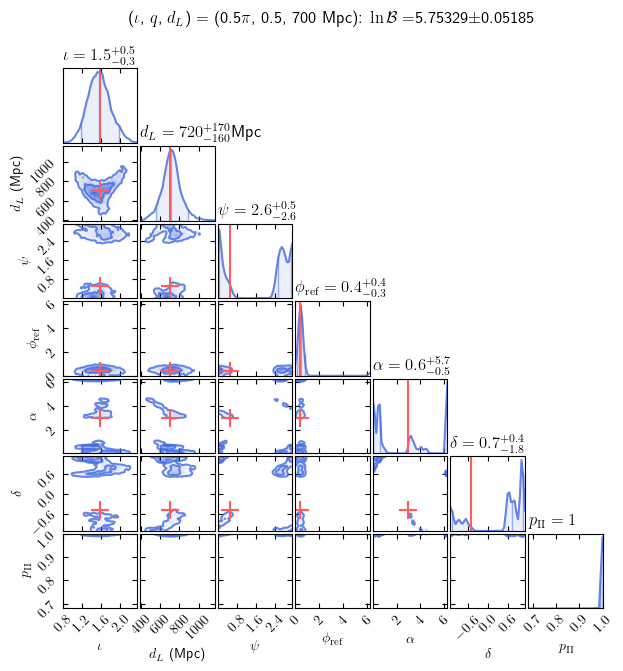

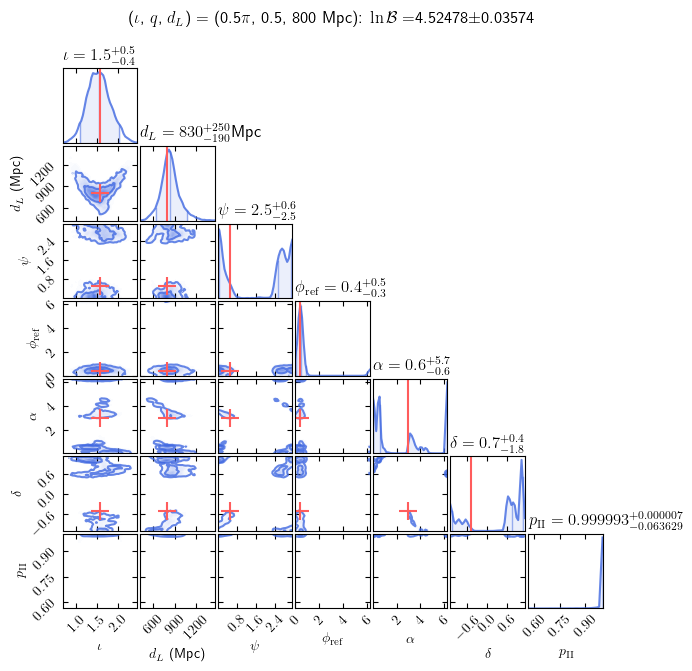

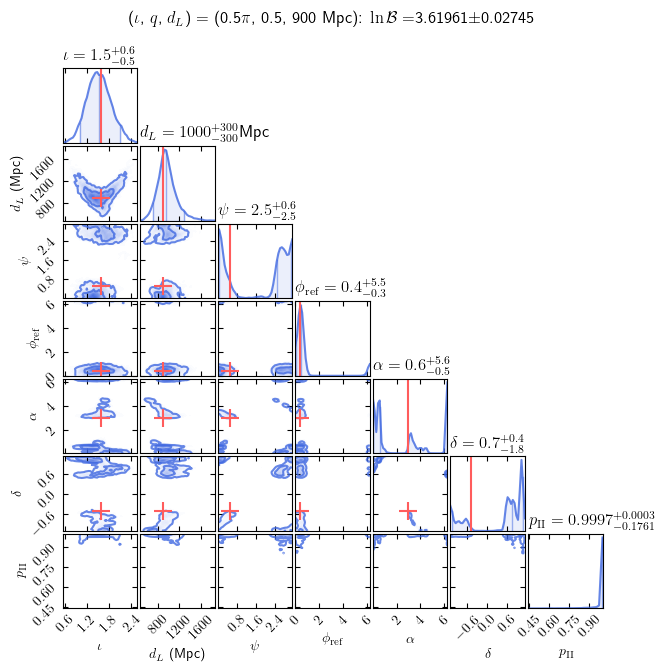

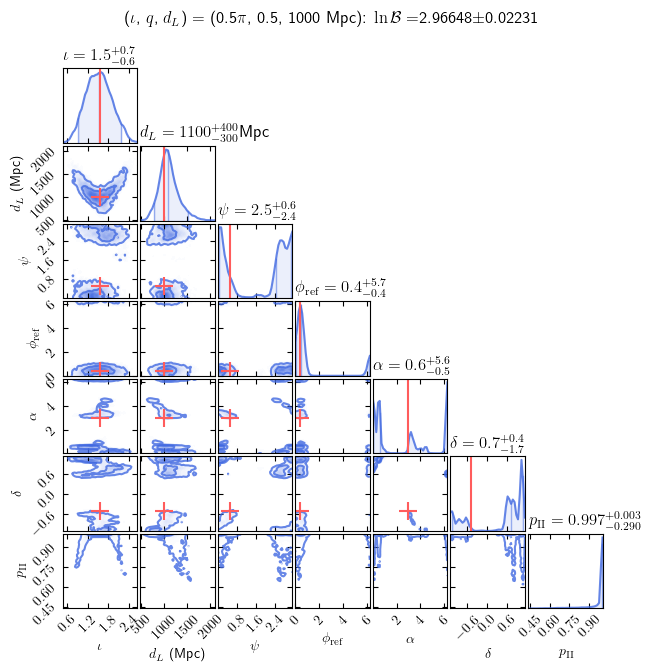

In [10]:
# which parameters to plot
pars_to_plot = [
    'iota',
    'd_luminosity',
    'psi',
    'phi_ref',
    'ra',
    'dec',
    'p_lensed'
]
c1, c2 = 'royalblue', 'mediumseagreen'

corner_plot_kwargs = dict(tail_probability=1e-3, color_2d='royalblue',
    kwargs_1d=dict(color='royalblue', alpha=0.8), contour_kwargs=dict(alpha=0.8))

for dL in dLs:
    # load this sample
    eventname = f'GW{seed}_iota-{iota / np.pi:.2f}_q-{q:.2f}_dL-{int(dL)}Mpc'
    eventdir = os.path.join(resdir, eventname)
    event_data, samples = load_event_data_and_posterior_samples(eventdir, eventname)

    try:
        injected_par_dict = event_data.get_init_dict()['injection']['par_dic']
    except AttributeError:
        continue
    # injected parameters to plot
    # get the subset of the data release posterior parameters
    injected_pars_to_plot = {}
    for key, value in injected_par_dict.items():
        if key in pars_to_plot:
            injected_pars_to_plot[key] = value

    # Bayes factor
    bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
    # log these
    lnbayes_factors = np.log(bayes_factors)
    # get the median and standard deviation
    lnbayes, lnbayes_std = np.median(lnbayes_factors), np.std(lnbayes_factors)
    
    # plot
    corner_plot = cogwheel.gw_plotting.CornerPlot(samples, params=pars_to_plot, **corner_plot_kwargs)

    # # compare the posteriors between the lensed and unlensed samples
    # lensed_idx = samples['lensed']

    # plotstyles = [
    #         cogwheel.plotting.PlotStyle(color_2d=c1, kwargs_1d=dict(color=c1), tail_probability=1e-3),
    #         cogwheel.plotting.PlotStyle(color_2d=c2, contour_kwargs=dict(alpha=0.6), kwargs_1d=dict(color=c2, alpha=0.6),
    #         tail_probability=1e-3)
    # ]

    # corner_plot = cogwheel.gw_plotting.MultiCornerPlot(
    #         {'lensed' : samples[lensed_idx], 'unlensed' : samples[~lensed_idx]}, params=pars_to_plot,
    #         density=False, plotstyles=plotstyles
    # )
    title_str = r'($\iota$, $q$, $d_L$) = ('f'{iota / np.pi:.1f}'r'$\pi$'f', {q:.1f}, {int(dL)} Mpc): ' + \
                r'$\ln\mathcal B =$'f'{lnbayes:.5f}'r'$\pm$' + f'{lnbayes_std:.5f}'
    try:
        corner_plot.plot(max_figsize=7)
    except ValueError:
        print("ValueError: plotting without p_lensed")
        pars_no_plensed = pars_to_plot.copy()
        pars_no_plensed = pars_no_plensed.remove("p_lensed")
        try:
            corner_plot = cogwheel.gw_plotting.CornerPlot(samples, params=pars_no_plensed, **corner_plot_kwargs)
            corner_plot.plot(max_figsize=7)
        except ValueError:
            print("another ValueError... continuing to next injection")
            continue

    corner_plot.fig.suptitle(title_str, y=0.97) # .corner_plots[0]
    corner_plot.scatter_points(injected_pars_to_plot, colors=['#FF5C5C'], s=150,
                                        zorder=2, marker='+', adjust_lims=True)